In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.float_format', '{:.2f}'.format)

# Load
df = pd.read_csv('../data/raw/PJM_Load_hourly.csv')
print(df.shape)
print(df.dtypes)
df.head(10)

(32896, 2)
Datetime        object
PJM_Load_MW    float64
dtype: object


,Datetime,PJM_Load_MW
0,1998-12-31 01:00:00,29309.00
1,1998-12-31 02:00:00,28236.00
2,1998-12-31 03:00:00,27692.00
3,1998-12-31 04:00:00,27596.00
4,1998-12-31 05:00:00,27888.00
5,1998-12-31 06:00:00,29382.00
6,1998-12-31 07:00:00,31373.00
7,1998-12-31 08:00:00,33272.00
8,1998-12-31 09:00:00,34133.00
9,1998-12-31 10:00:00,35232.00


In [4]:
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.sort_values('Datetime').reset_index(drop=True)
df = df.rename(columns={'PJM_Load_MW': 'energy_mw'})

print(f"Date range: {df['Datetime'].min()} → {df['Datetime'].max()}")
print(f"Total hours: {len(df)}")
print(f"Expected hours: {(df['Datetime'].max() - df['Datetime'].min()).days * 24}")


Date range: 1998-04-01 01:00:00 → 2002-01-01 00:00:00
Total hours: 32896
Expected hours: 32880


In [5]:
# Missing values
print("Missing values:", df['energy_mw'].isna().sum())

# Duplicated timestamps
dupes = df.duplicated(subset='Datetime', keep=False)
print("Duplicate timestamps:", dupes.sum())
if dupes.sum() > 0:
    print(df[dupes].head(10))

# Check for gaps in the hourly sequence
df_indexed = df.set_index('Datetime')
full_range = pd.date_range(start=df_indexed.index.min(), 
                           end=df_indexed.index.max(), freq='h')
missing_timestamps = full_range.difference(df_indexed.index)
print(f"\nMissing timestamps: {len(missing_timestamps)}")
print(missing_timestamps[:10])

Missing values: 0
Duplicate timestamps: 0

Missing timestamps: 8
DatetimeIndex(['1998-04-05 03:00:00', '1998-10-25 02:00:00',
               '1999-04-04 03:00:00', '1999-10-31 02:00:00',
               '2000-04-02 03:00:00', '2000-10-29 02:00:00',
               '2001-04-01 03:00:00', '2001-10-28 02:00:00'],
              dtype='datetime64[ns]', freq=None)


## Data Quality Notes:
- 32,896 hourly observations from April 1998 to January 2002;
- No missing values, no duplicate timestamps;
- 8 missing timestamps due to DST spring-forward transitions (will interpolate in Phase 2);
- Target column: energy_mw (float64), range to be confirmed in Block 4.

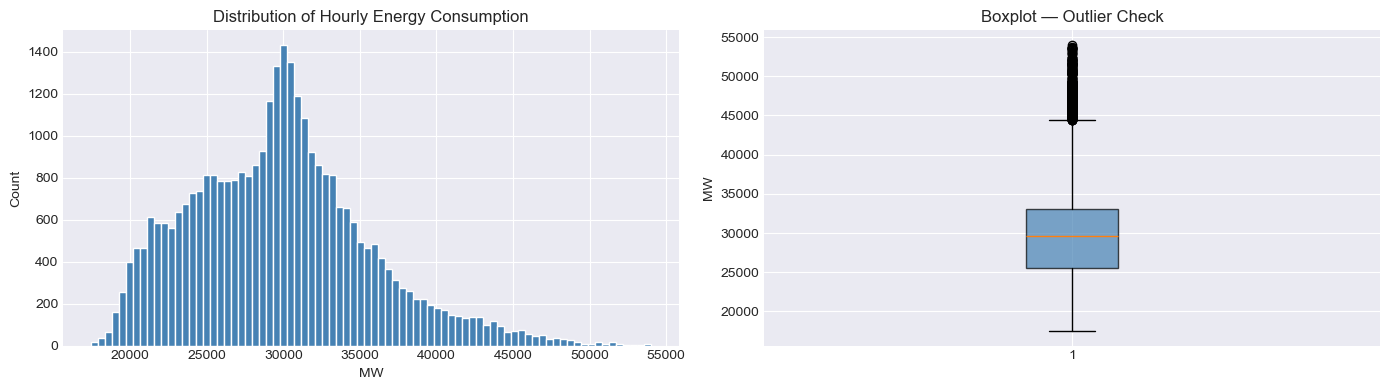

count   32896.00
mean    29766.43
std      5849.77
min     17461.00
25%     25473.00
50%     29655.00
75%     33073.25
max     54030.00
Name: energy_mw, dtype: float64


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram
axes[0].hist(df['energy_mw'], bins=80, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Hourly Energy Consumption')
axes[0].set_xlabel('MW')
axes[0].set_ylabel('Count')

# Boxplot
axes[1].boxplot(df['energy_mw'].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_title('Boxplot — Outlier Check')
axes[1].set_ylabel('MW')

plt.tight_layout()
plt.show()

print(df['energy_mw'].describe())

## Distribution Analysis:
- Mean consumption: ~29,766 MW, std: ~5,850 MW;
- Right-skewed distribution —> peak summer hours pull the tail up to 54,030 MW;
- No statistical outliers detected —> extreme values are real peak demand events;
- Wide range (17k -> 54k MW) driven by seasonal and daily cycles. 

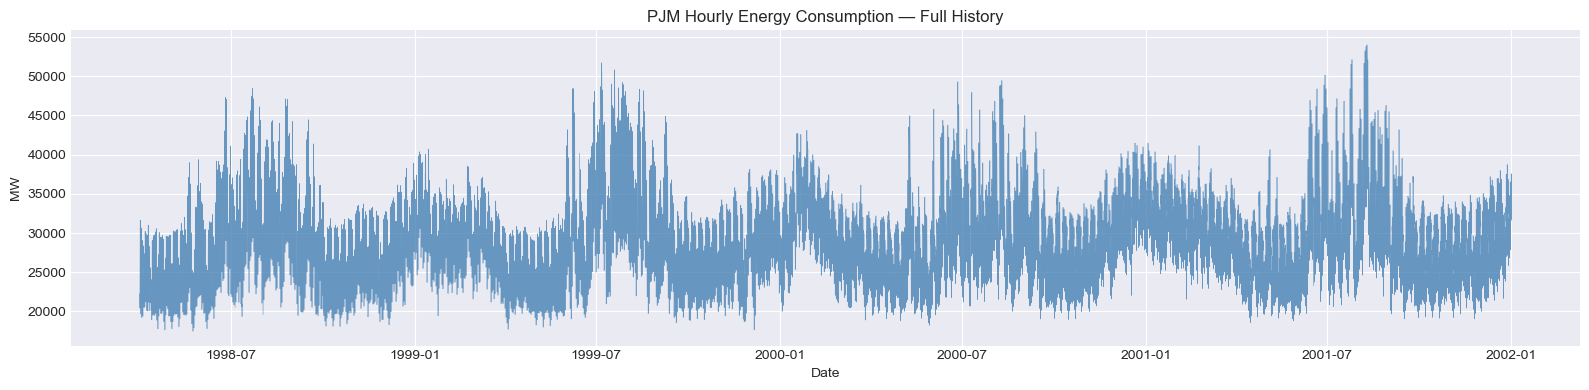

In [8]:
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(df['Datetime'], df['energy_mw'], linewidth=0.4, color='steelblue', alpha=0.8)
ax.set_title('PJM Hourly Energy Consumption — Full History')
ax.set_xlabel('Date')
ax.set_ylabel('MW')
plt.tight_layout()
plt.show()

## Full History Plot:
- Clear yearly seasonality: summer peaks (cooling) and elevated winter baseline (heating);
- Spring and autumn show lowest consumption — mild weather, minimal HVAC load;
- Daily cycle visible as dense vertical bands across the entire series;
- No structural breaks or anomalies detected across the 1998–2002 period.

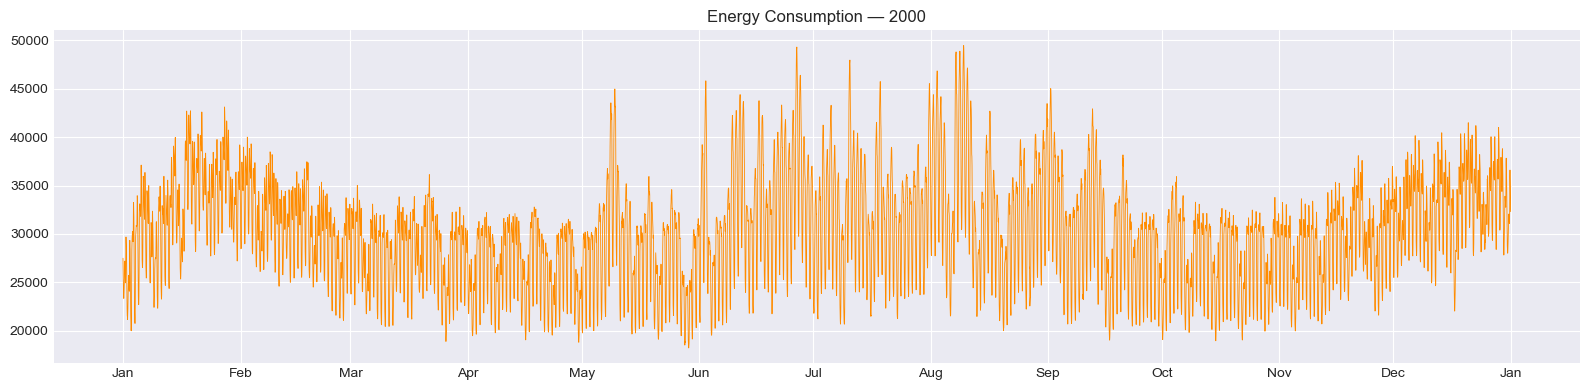

In [9]:
one_year = df[df['Datetime'].dt.year == 2000]

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(one_year['Datetime'], one_year['energy_mw'], linewidth=0.6, color='darkorange')
ax.set_title('Energy Consumption — 2000')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.tight_layout()
plt.show()


## Single Year Analysis (2000):
- Double-peak pattern: summer cooling peak (Jul/Aug ~48k MW) > winter heating peak (Jan ~42k MW);
- Lowest consumption: April/May — mild weather, minimal HVAC;
- Clear weekly rhythm visible throughout the year (weekend dips);
- Daily swing is largest in summer: hot afternoons vs cool nights.

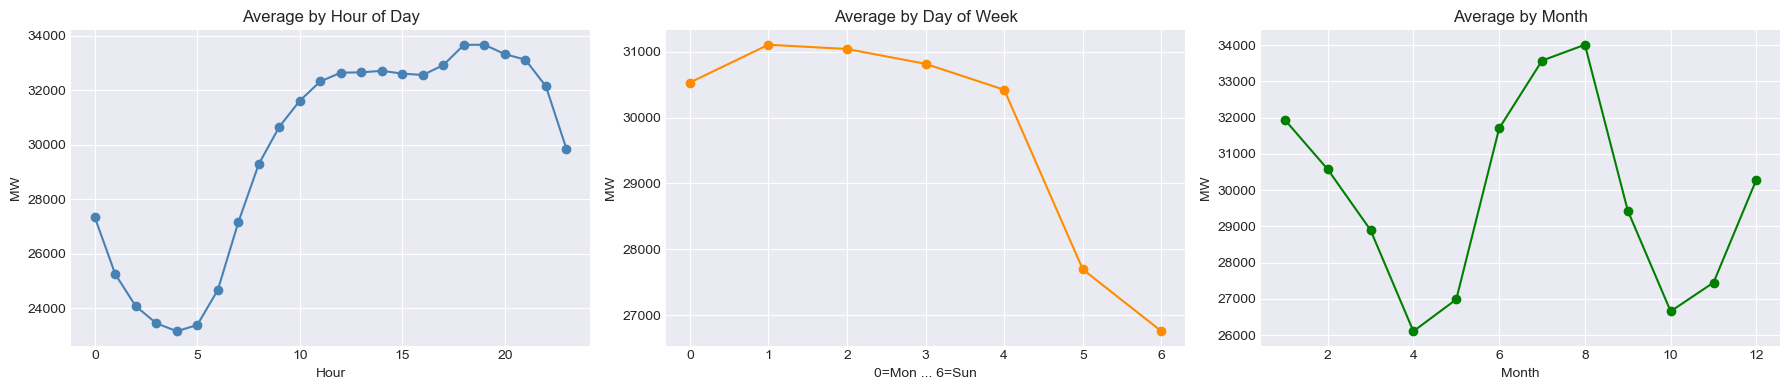

In [10]:
df['hour'] = df['Datetime'].dt.hour
df['dayofweek'] = df['Datetime'].dt.dayofweek  # 0=Mon, 6=Sun
df['month'] = df['Datetime'].dt.month

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Hourly pattern
df.groupby('hour')['energy_mw'].mean().plot(ax=axes[0], marker='o', color='steelblue')
axes[0].set_title('Average by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('MW')

# Day of week pattern
df.groupby('dayofweek')['energy_mw'].mean().plot(ax=axes[1], marker='o', color='darkorange')
axes[1].set_title('Average by Day of Week')
axes[1].set_xlabel('0=Mon ... 6=Sun')
axes[1].set_ylabel('MW')

# Monthly pattern
df.groupby('month')['energy_mw'].mean().plot(ax=axes[2], marker='o', color='green')
axes[2].set_title('Average by Month')
axes[2].set_xlabel('Month')
axes[2].set_ylabel('MW')

plt.tight_layout()
plt.show()

## Seasonality Patterns
- Hourly: smooth daily cycle, trough at 4-5am (~ 24k MW), peak at 1-3pm (~ 33.5k MW);
- Weekly: clear weekday/weekend split — Sunday is ~13% below Monday;
- Monthly: double-peak year (July > January > April/October);
- All three cycles must be captured as features in the model.

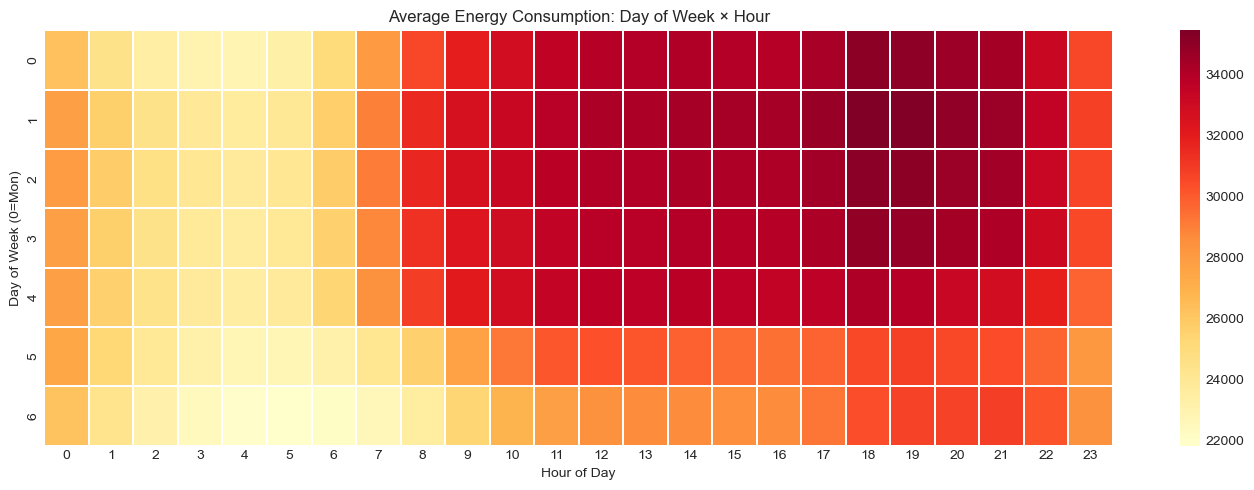

In [11]:
pivot = df.groupby(['dayofweek', 'hour'])['energy_mw'].mean().unstack()

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot, cmap='YlOrRd', ax=ax, linewidths=0.1)
ax.set_title('Average Energy Consumption: Day of Week × Hour')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Day of Week (0=Mon)')
plt.tight_layout()
plt.show()